## All required commands to install MLflow on EC2:

In [1]:
#creating baseline model

import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [3]:
df.dropna(inplace=True)

In [4]:
df.drop_duplicates(inplace=True)

In [5]:
df = df[~(df['clean_comment'].str.strip() == '')]

In [6]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [7]:
# Define the preprocessing function
def preprocess_comment(comment):
    # Convert to lowercase
    comment = comment.lower()

    # Remove trailing and leading whitespaces
    comment = comment.strip()

    # Remove newline characters
    comment = re.sub(r'\n', ' ', comment)

    # Remove non-alphanumeric characters, except punctuation
    comment = re.sub(r'[^A-Za-z0-9\s!?.,]', '', comment)

    # Remove stopwords but retain important ones for sentiment analysis
    stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'}
    comment = ' '.join([word for word in comment.split() if word not in stop_words])

    # Lemmatize the words
    lemmatizer = WordNetLemmatizer()
    comment = ' '.join([lemmatizer.lemmatize(word) for word in comment.split()])

    return comment

In [8]:
# Apply the preprocessing function to the 'clean_comment' column
df['clean_comment'] = df['clean_comment'].apply(preprocess_comment)

In [9]:
df.head()

,clean_comment,category
0,family mormon never tried explain still stare ...,1
1,buddhism much lot compatible christianity espe...,1
2,seriously say thing first get complex explain ...,-1
3,learned want teach different focus goal not wr...,0
4,benefit may want read living buddha living chr...,1


In [10]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\TEST\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
# Step 1: Vectorize the comments using Bag of Words (CountVectorizer)
vectorizer = CountVectorizer(max_features=10000)  # Bag of Words model with a limit of 1000 features

In [12]:
X = vectorizer.fit_transform(df['clean_comment']).toarray()
y = df['category']  # Assuming 'sentiment' is the target variable (0 or 1 for binary classification)

In [13]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(36793, 10000))

In [14]:
X.shape

(36793, 10000)

In [15]:
y

0        1
1        1
2       -1
3        0
4        1
        ..
37244    0
37245    1
37246    0
37247    1
37248    0
Name: category, Length: 36793, dtype: int64

In [16]:
y.shape

(36793,)

In [17]:
# Step 2: Set up the MLflow tracking server
mlflow.set_tracking_uri("http://ec2-15-188-118-200.eu-west-3.compute.amazonaws.com:5000/")

In [18]:
# Set or create an experiment
mlflow.set_experiment("RF Baseline")

2026/04/17 10:41:05 INFO mlflow.tracking.fluent: Experiment with name 'RF Baseline' does not exist. Creating a new experiment.


<Experiment: artifact_location='s3://mlflow-bucket-sami/1', creation_time=1776418865357, experiment_id='1', last_update_time=1776418865357, lifecycle_stage='active', name='RF Baseline', tags={}, trace_location=None, workspace='default'>

2026/04/17 11:26:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 11:26:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RandomForest_Baseline_TrainTestSplit at: http://ec2-15-188-118-200.eu-west-3.compute.amazonaws.com:5000/#/experiments/1/runs/f9ec2d9b07bf413c8928911d13b13b3f
🧪 View experiment at: http://ec2-15-188-118-200.eu-west-3.compute.amazonaws.com:5000/#/experiments/1
Accuracy : 0.6695203152602256


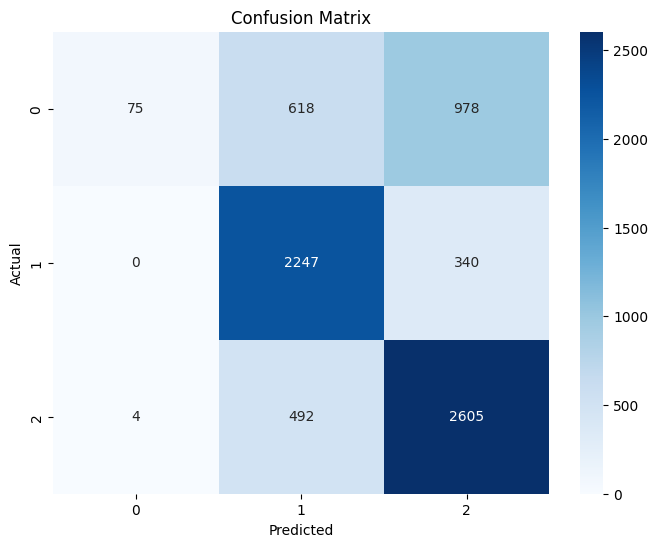

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

with mlflow.start_run() as run:

    mlflow.set_tag('mlflow.runName','RandomForest_Baseline_TrainTestSplit')
    mlflow.set_tag('experiment_type','baseline')
    mlflow.set_tag('model_type','RandomForestClassifier')

    mlflow.set_tag('description','Baseline RandomForest model for sentiment analysis using Bag of Words (BoW) with CountVectorizer')

    mlflow.log_param('vectorizer_type','CountVectorizer')
    mlflow.log_param('vectorizer_max_features',vectorizer.max_features)

    n_estimators = 400
    max_depth = 25

    mlflow.log_param('n_estimators',400)
    mlflow.log_param('max_depth',25)

    model = RandomForestClassifier(n_estimators=n_estimators,max_depth=max_depth,random_state=42)
    model.fit(X_train,y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test,y_pred)
    mlflow.log_metric('accuracy',accuracy)

    classification_rep = classification_report(y_test,y_pred,output_dict=True)

    for label, metrics in classification_rep.items():
        if isinstance(metrics,dict):
            for metric,value in metrics.items():
                mlflow.log_metric(f"{label}_{metric}", value)


    conf_matrix = confusion_matrix(y_test,y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')

    plt.savefig('confusion_matrix.png')

    mlflow.log_artifact('confusion_matrix.png')

    mlflow.sklearn.log_model(model,'random_forest_model')

    df.to_csv('dataset.csv',index=False)

    mlflow.log_artifact('dataset.csv')


print(f"Accuracy : {accuracy}")
    

In [24]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          -1       0.95      0.04      0.09      1671
           0       0.67      0.87      0.76      2587
           1       0.66      0.84      0.74      3101

    accuracy                           0.67      7359
   macro avg       0.76      0.58      0.53      7359
weighted avg       0.73      0.67      0.60      7359



In [25]:
df.to_csv('reddit_preprocessing.csv',index=False)

In [26]:
pd.read_csv('reddit_preprocessing.csv').head()

,clean_comment,category
0,family mormon never tried explain still stare ...,1
1,buddhism much lot compatible christianity espe...,1
2,seriously say thing first get complex explain ...,-1
3,learned want teach different focus goal not wr...,0
4,benefit may want read living buddha living chr...,1
